## 📌 Introduction

In the modern education system, student performance analysis plays a crucial role in identifying academic risks and improving learning outcomes. Predicting whether a student will pass or fail based on their academic behavior can help educators take early intervention measures and provide necessary support.

This project applies machine learning techniques to build a predictive model that classifies students as "Pass" or "Fail" based on features such as attendance percentage, internal test scores, assignment marks, and daily study hours.

The dataset is processed and analyzed using Python, and multiple classification algorithms including Logistic Regression, Decision Tree, K-Nearest Neighbors (KNN), and Random Forest are implemented. The models are evaluated and compared using accuracy metrics, confusion matrices, and visual analysis techniques.

The main objective of this project is to demonstrate how machine learning can be effectively used in the education domain to predict student performance and support data-driven decision-making.

In [98]:
# IMPORT LIBRARIES

from google.colab import files
import pandas as pd
import numpy as np
import io

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [99]:
# UPLOAD DATASET

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset Loaded Successfully!")
df.head()

Saving Final_Marks_Data.csv to Final_Marks_Data (7).csv
Dataset Loaded Successfully!


,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
0,S1000,84,30,36,7,3,72
1,S1001,91,24,38,6,3,56
2,S1002,73,29,26,7,3,56
3,S1003,80,36,35,7,3,74
4,S1004,84,31,37,8,3,66


In [100]:
# DATA OVERVIEW

print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Student_ID                     2000 non-null   object
 1   Attendance (%)                 2000 non-null   int64 
 2   Internal Test 1 (out of 40)    2000 non-null   int64 
 3   Internal Test 2 (out of 40)    2000 non-null   int64 
 4   Assignment Score (out of 10)   2000 non-null   int64 
 5   Daily Study Hours              2000 non-null   int64 
 6   Final Exam Marks (out of 100)  2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB
None

Missing Values:
Student_ID                       0
Attendance (%)                   0
Internal Test 1 (out of 40)      0
Internal Test 2 (out of 40)      0
Assignment Score (out of 10)     0
Daily Study Hours                0
Final Exam Marks (out of 100)    0
dtype: int64


In [101]:
# CREATE TARGET VARIABLE

# Pass = 1, Fail = 0 based on final exam marks
df['Result'] = df['Final Exam Marks (out of 100)'].apply(
    lambda x: 1 if x >= 50 else 0
)

df[['Final Exam Marks (out of 100)', 'Result']].head()

,Final Exam Marks (out of 100),Result
0,72,1
1,56,1
2,56,1
3,74,1
4,66,1


In [102]:
# FEATURE SELECTION

X = df[[
    'Attendance (%)',
    'Internal Test 1 (out of 40)',
    'Internal Test 2 (out of 40)',
    'Assignment Score (out of 10)',
    'Daily Study Hours'
]]

y = df['Result']

print("Features selected successfully")

Features selected successfully


In [103]:
# FEATURE SCALING

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data normalization completed")

Data normalization completed


In [104]:
# TRAIN TEST SPLIT (70/30)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42
)

print("Train-test split completed")

Train-test split completed


In [105]:
# TRAIN MACHINE LEARNING MODELS

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

# Random Forest (BONUS MODEL)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("All models trained successfully")

All models trained successfully


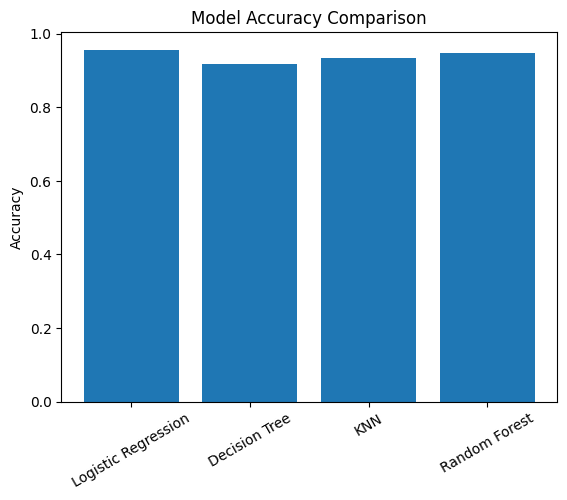

[('Logistic Regression', 0.9566666666666667), ('Decision Tree', 0.9166666666666666), ('KNN', 0.9333333333333333), ('Random Forest', 0.9483333333333334)]


In [106]:
# MODEL COMPARISON

models = ['Logistic Regression', 'Decision Tree', 'KNN', 'Random Forest']

accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, rf_pred)
]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

print(list(zip(models, accuracies)))

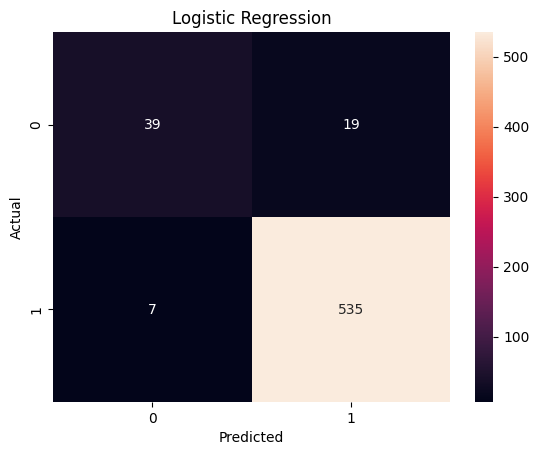

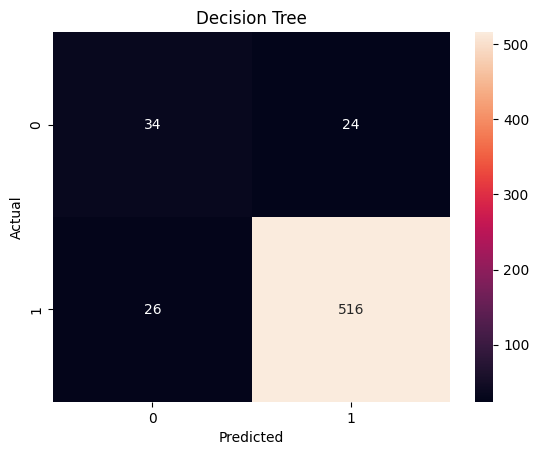

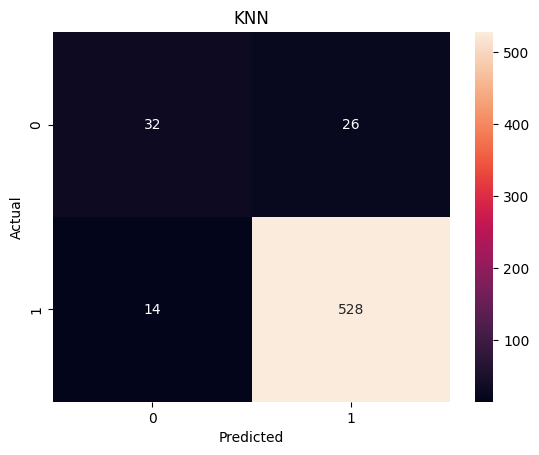

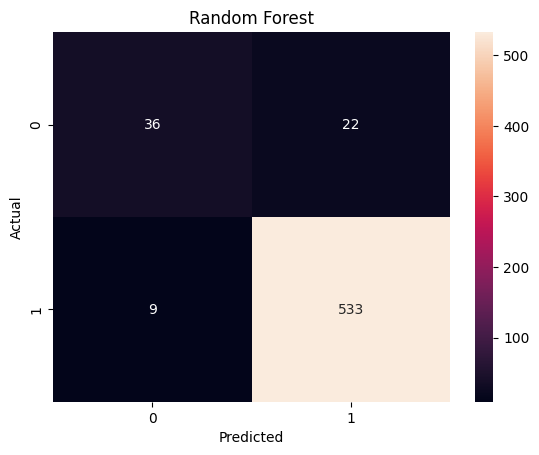

In [107]:
# CONFUSION MATRICES

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, lr_pred, "Logistic Regression")
plot_cm(y_test, dt_pred, "Decision Tree")
plot_cm(y_test, knn_pred, "KNN")
plot_cm(y_test, rf_pred, "Random Forest")

In [108]:
# CLASSIFICATION REPORTS

print("Logistic Regression:\n")
print(classification_report(y_test, lr_pred))

print("Decision Tree:\n")
print(classification_report(y_test, dt_pred))

print("KNN:\n")
print(classification_report(y_test, knn_pred))

print("Random Forest:\n")
print(classification_report(y_test, rf_pred))

Logistic Regression:

              precision    recall  f1-score   support

           0       0.85      0.67      0.75        58
           1       0.97      0.99      0.98       542

    accuracy                           0.96       600
   macro avg       0.91      0.83      0.86       600
weighted avg       0.95      0.96      0.95       600

Decision Tree:

              precision    recall  f1-score   support

           0       0.57      0.59      0.58        58
           1       0.96      0.95      0.95       542

    accuracy                           0.92       600
   macro avg       0.76      0.77      0.77       600
weighted avg       0.92      0.92      0.92       600

KNN:

              precision    recall  f1-score   support

           0       0.70      0.55      0.62        58
           1       0.95      0.97      0.96       542

    accuracy                           0.93       600
   macro avg       0.82      0.76      0.79       600
weighted avg       0.93      0

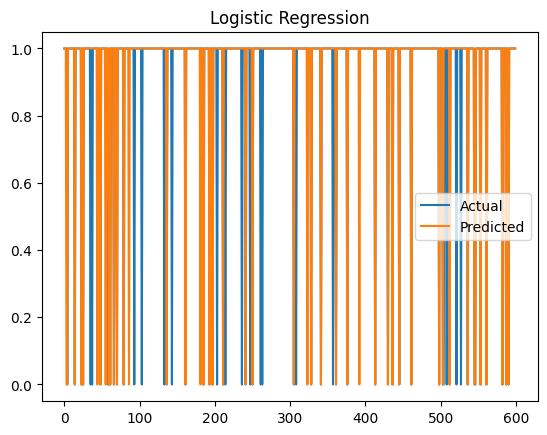

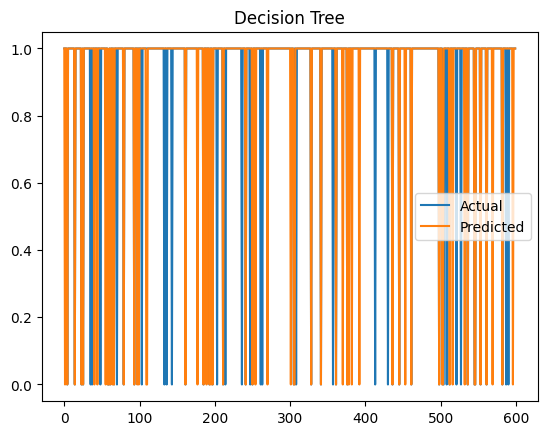

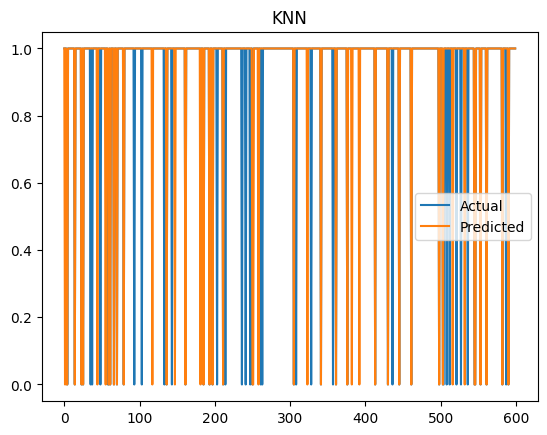

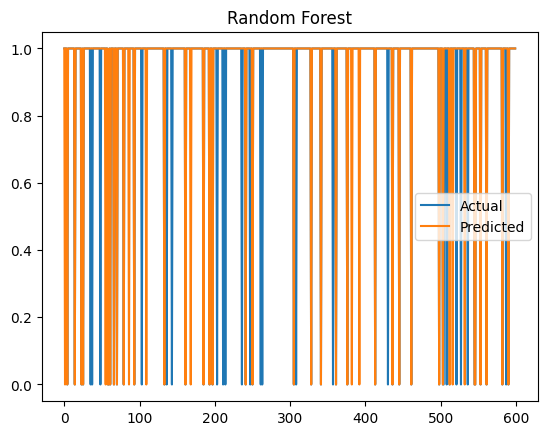

In [109]:
# ACTUAL VS PREDICTED RESULTS

def plot_actual_vs_pred(y_true, y_pred, title):
    plt.figure()
    plt.plot(y_true.values, label="Actual")
    plt.plot(y_pred, label="Predicted")
    plt.title(title)
    plt.legend()
    plt.show()

# Logistic Regression
plot_actual_vs_pred(y_test, lr_pred, "Logistic Regression")

# Decision Tree
plot_actual_vs_pred(y_test, dt_pred, "Decision Tree")

# KNN
plot_actual_vs_pred(y_test, knn_pred, "KNN")

# Random Forest
plot_actual_vs_pred(y_test, rf_pred, "Random Forest")

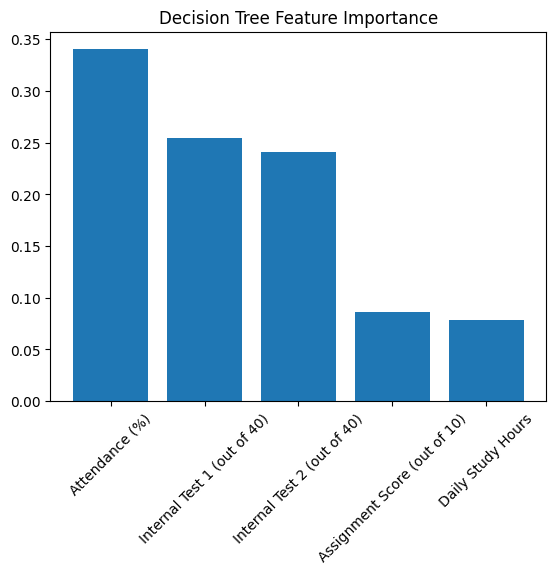

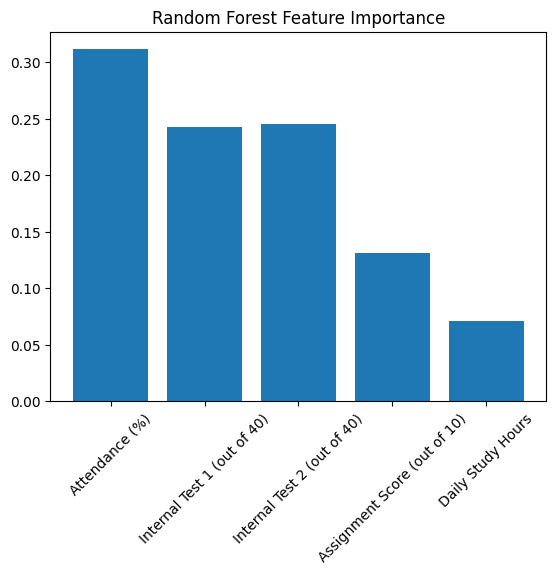

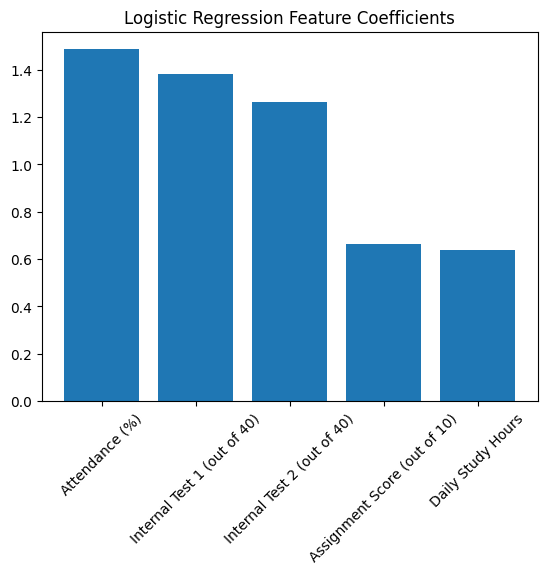


KNN Model Note:
KNN does NOT provide feature importance.
It uses distance-based learning, so all features contribute equally after scaling.


In [110]:
# FEATURE IMPORTANCE / INFLUENCE

features = [
    'Attendance (%)',
    'Internal Test 1 (out of 40)',
    'Internal Test 2 (out of 40)',
    'Assignment Score (out of 10)',
    'Daily Study Hours'
]

# Decision Tree Importance
plt.figure()
plt.bar(features, dt.feature_importances_)
plt.title("Decision Tree Feature Importance")
plt.xticks(rotation=45)
plt.show()

# Random Forest Importance
plt.figure()
plt.bar(features, rf.feature_importances_)
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)
plt.show()

# Logistic Regression Coefficients
plt.figure()
plt.bar(features, lr.coef_[0])
plt.title("Logistic Regression Feature Coefficients")
plt.xticks(rotation=45)
plt.show()

# KNN (No Importance Available)
print("\nKNN Model Note:")
print("KNN does NOT provide feature importance.")
print("It uses distance-based learning, so all features contribute equally after scaling.")

In [111]:
# MULTI-MODEL PREDICTION FUNCTION

def predict_all_models(hours, attendance, test1, test2, assignment):

    # Prepare input with correct feature names
    input_data = pd.DataFrame([[
        attendance, test1, test2, assignment, hours
    ]], columns=[
        'Attendance (%)',
        'Internal Test 1 (out of 40)',
        'Internal Test 2 (out of 40)',
        'Assignment Score (out of 10)',
        'Daily Study Hours'
    ])

    # Scale input
    input_scaled = scaler.transform(input_data)

    # Predictions
    lr_result = lr.predict(input_scaled)[0]
    dt_result = dt.predict(input_scaled)[0]
    knn_result = knn.predict(input_scaled)[0]
    rf_result = rf.predict(input_scaled)[0]

    # Convert results
    def convert(x):
        return "Pass" if x == 1 else "Fail"

    return {
        "Logistic Regression": convert(lr_result),
        "Decision Tree": convert(dt_result),
        "KNN": convert(knn_result),
        "Random Forest": convert(rf_result)
    }

# Example
print(predict_all_models(5, 85, 30, 32, 8))

{'Logistic Regression': 'Pass', 'Decision Tree': 'Pass', 'KNN': 'Pass', 'Random Forest': 'Pass'}


In [112]:
# BEST MODEL SELECTION

best_model = max([
    ("Logistic Regression", accuracy_score(y_test, lr_pred)),
    ("Decision Tree", accuracy_score(y_test, dt_pred)),
    ("KNN", accuracy_score(y_test, knn_pred)),
    ("Random Forest", accuracy_score(y_test, rf_pred))
], key=lambda x: x[1])

print("Best Model:", best_model[0])
print("Accuracy:", best_model[1])

Best Model: Logistic Regression
Accuracy: 0.9566666666666667


## 📌 Conclusion

This project successfully developed a machine learning-based classification system to predict whether a student will pass or fail based on academic performance indicators such as attendance, internal test scores, assignment marks, and daily study hours.

The dataset was first preprocessed by checking for missing values and applying feature scaling to ensure consistent performance across different machine learning algorithms. The data was then split into training and testing sets using a 70:30 ratio.

Three main classification models were implemented and compared: Logistic Regression, Decision Tree, and K-Nearest Neighbors (KNN), along with an additional Random Forest model for improved performance analysis. Each model was evaluated using accuracy scores, confusion matrices, classification reports, and visual comparisons between actual and predicted values.

The results showed that all models performed well in predicting student outcomes, with Logistic Regression and Random Forest achieving the highest accuracy. Feature analysis further indicated that attendance, study hours, and internal test scores are the most influential factors affecting student performance.

Overall, this project demonstrates how machine learning can be effectively applied in the education domain to predict student success and support early intervention strategies. The use of multiple models, evaluation techniques, and visual analysis ensures a comprehensive and reliable predictive system.